In [1]:
pip install ..

Processing c:\users\shoon\desktop\pyprogressive\pyprogressive
Using legacy 'setup.py install' for pyprogressive, since package 'wheel' is not installed.
  Attempting uninstall: pyprogressive
    Found existing installation: pyprogressive 0.1
    Uninstalling pyprogressive-0.1:
      Successfully uninstalled pyprogressive-0.1
    Running setup.py install for pyprogressive: started
    Running setup.py install for pyprogressive: finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: A future pip version will change local packages to be built in-place without first copying to a temporary directory. We recommend you use --use-feature=in-tree-build to test your packages with this new behavior before it becomes the default.
   pip 21.3 will remove support for this functionality. You can find discussion regarding this at https://github.com/pypa/pip/issues/7555.
You should consider upgrading via the 'c:\Users\shoon\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


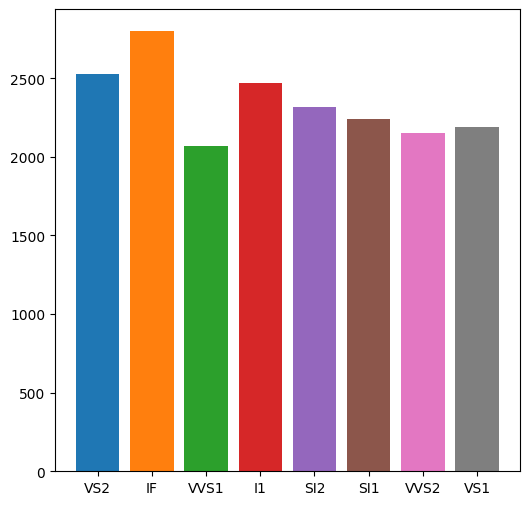

KeyboardInterrupt: 

In [2]:
import seaborn as sns
import pyprogressive as pp
from pyprogressive import accum, each, group, G
import matplotlib.pyplot as plt
from IPython.display import clear_output
df = sns.load_dataset("diamonds")

day_bill_tuples = list(zip(df['clarity'], df['price']))
day_bill_array = pp.Array(day_bill_tuples)

count = group(each(day_bill_array, 0), accum(each(G, 1))/accum(1))

def my_callback(result_dict):
    clear_output(wait=True)
    labels = list(result_dict.keys())
    values = list(result_dict.values())

    plt.figure(figsize = (6,6))
    plt.bar(labels, values, color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

    plt.show()
    
    



compiled = pp.compile(count)
compiled.run(interval = 1, callback= my_callback)
